# AI for Cognitive Ultrasound Imaging
### IEEE IUS 2026 Short Course

Welcome! In this hands-on notebook we build a basic **perception-action loop** that drives intelligent, adaptive focused transmit steering, a core idea behind cognitive ultrasound.

We use a [Flow Matching model](https://zea.readthedocs.io/en/latest/_autosummary/zea.models.flow_matching.html#zea.models.flow_matching.FlowMatchingModel) (the modern, faster-sampling cousin of diffusion models, now native in [`zea`](https://github.com/tue-bmd/zea)) to implement perception-as-inference, with [greedy entropy minimization](https://zea.readthedocs.io/en/latest/_autosummary/zea.agent.selection.html#zea.agent.selection.GreedyEntropy) as our action selection policy.

The agent acts on a **real recording**: a parasternal long-axis (PLAX) cine acquired with a Verasonics S5-1 phased array, stored as raw channel data. Every line the agent asks for is beamformed on the spot from the channel data of that one focused transmit, so its measurements are the measurements a scanner would actually have produced had it fired only those transmits.

This notebook accompanies the IEEE IUS 2026 short course [AI for Cognitive Ultrasound Imaging](https://ieee-ius.org/2026/short-course/ai-for-cognitive-ultrasound-imaging), organized by Yonina Eldar, Marcin Lewandowski and Ruud van Sloun. The notebook part of the course is brought to you by [Tristan Stevens](https://github.com/tristan-deep), [Oisín Nolan](https://github.com/OisinNolan) and [Wessel van Nierop](https://github.com/wesselvannierop), maintainers of `zea`.

Feel free to play around with the settings throughout, this notebook is meant to be explored, not just run! 🚀

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/ius-2026-cogus-workshop/blob/main/ius_2026_cogus_workshop.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/ius-2026-cogus-workshop/blob/main/ius_2026_cogus_workshop.ipynb)
&nbsp;
[![Hugging Face model](https://img.shields.io/badge/Hugging%20Face-Model-yellow?logo=huggingface)](https://huggingface.co/zeahub/flowmatching-echonetlvh)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Running on CPU may be very slow.

If you are running in Colab (recommended, click the badge above), enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀

In [49]:
%%capture
%pip install "zea[jax]>=0.1.6" tabulate

In [50]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [51]:
# The beamforming profile and the three scan-line operations live next to this
# notebook; on Colab, fetch them from the workshop repo.
import pathlib
import urllib.request

REPO = "https://raw.githubusercontent.com/tue-bmd/ius-2026-cogus-workshop/main"

pathlib.Path("pipeline").mkdir(exist_ok=True)
for filename in ("ops.py", "s5-1.yaml"):
    path = pathlib.Path("pipeline") / filename
    if not path.exists():
        urllib.request.urlretrieve(f"{REPO}/pipeline/{filename}", path)

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from keras import ops
from matplotlib import animation
from tabulate import tabulate
from tqdm import tqdm

import zea
from zea import init_device, metrics
from zea.agent import masks
from zea.agent.selection import EquispacedLines, GreedyEntropy, UniformRandomLines
from zea.config import Config
from zea.func import translate
from zea.models.flow_matching import FlowMatchingModel
from zea.models.lpips import LPIPS
from zea.ops import Pipeline, ScanConvert
from zea.visualize import plot_image_grid, set_mpl_style

# Registers `select_scanlines`, `map_scanlines` and `stack_scanlines`, the only three
# operations in the beamforming profile that `zea` does not ship natively.
from pipeline import ops as scanline_ops  # noqa: F401

In [53]:
n_prior_samples = 4  # particles representing the unconditional prior belief
n_unconditional_steps = 100  # flow steps used for unconditional prior sampling
n_conditional_samples = 2  # particles representing the posterior belief
n_conditional_steps = 200  # length of the full posterior flow schedule
n_initial_conditional_steps = 120  # starting step when warm-starting
conditional_omega = 1.0  # measurement-guidance strength
n_actions = 7  # focused transmits fired per frame, out of the 56 in the recording
n_frames = 32  # frames of the recording to replay
hard_project = False  # exactly restore acquired pixels in displayed/scored reconstructions


We will work with the GPU if available, and initialize using `init_device` to pick the best available device. Also, (optionally), we will set the matplotlib style for plotting.

In [54]:
init_device(verbose=False)
set_mpl_style()

## Load the recording and the model

The generative model and the agent both live in the **polar** domain: the raw acquisition
grid, where one focused transmit is exactly one column of pixels. That is not what a scanner
puts on screen, so we only scan convert at the very end, for plotting. Scan converting up
front would mean acquiring "lines" of an image that has already been warped into a fan, and
the agent would be steering in the wrong coordinates.

Here that grid is not a convention we impose on an image dataset — it *is* the acquisition.
The recording holds raw channel data, `(n_frames, n_transmits, n_samples, n_elements, 1)`,
for 56 focused transmits fanned out over a ±45° sector, and we reconstruct it with a `zea`
[`Pipeline`](https://zea.readthedocs.io/en/latest/_autosummary/zea.ops.Pipeline.html) built
from `pipeline/s5-1.yaml`:

```
select_scanlines -> cast -> band_pass_filter -> apply_window -> demodulate
                 -> map_scanlines[ tof_correction -> delay_and_sum
                                   -> reshape_grid -> envelope_detect ]
                 -> stack_scanlines -> normalize -> log_compress
```

The three `*_scanlines` operations (in `pipeline/ops.py`) are what make this pipeline
answer a *sparse* query: `select_scanlines` keeps only the columns whose indices we hand it,
`map_scanlines` beamforms each of those from its own transmit alone, and `stack_scanlines`
lays them back down side by side. Because every column is formed in isolation, a line looks
exactly the same whether it was acquired on its own or as part of a full frame — which is
what lets us answer the agent's query without ever forming the frames it did not ask for.

The prior is 112 columns wide over 56 rays, so every ray fills two adjacent model columns.

In [ ]:
# load generative model - flow matching replaces the older diffusion models used in earlier zea releases
# the prior models a short clip rather than a single frame: its channels are consecutive frames
model = FlowMatchingModel.from_preset(
    "hf://zeahub/flowmatching-echonetlvh/3ch-224x112"
)
frame_height, frame_width, n_model_frames = model.input_shape
vmin, vmax = model.input_range  # used throughout for plotting and preprocessing

# open the recording; zea streams hf:// files over HTTP, so only the frames we
# actually slice are fetched, not the whole 2.2 GB of channel data
file = zea.File("hf://zeahub/plax/20260223_S5-1_THI.hdf5", mode="r")
track = file.tracks[0]
parameters = track.load_parameters()

# the profile owns the whole acquisition model: the grid it is formed on, the receive
# aperture, the demodulation, and the display window
profile = Config.from_path("pipeline/s5-1.yaml")
dynamic_range = tuple(profile.display.dynamic_range)

# `parameters:` patches the recording's geometry (one grid column per transmit,
# a polar grid of steered rays, the depth range); the pipeline reads the handful of
# those that are actually inputs to an operation (`f_number`, `bandwidth`)
parameters.update(dict(profile.parameters))
beamformer = Pipeline.from_config(profile, with_batch_dim=False, jit_options="pipeline")
pipeline_parameters = beamformer.prepare_parameters(
    parameters,
    **{k: v for k, v in profile.parameters.items() if k in beamformer.needs_keys},
)
pipeline_parameters["dynamic_range"] = dynamic_range

n_lines = int(np.asarray(parameters.grid).shape[1])  # 56 rays = 56 possible actions
columns_per_line = frame_width // n_lines  # each ray fills two model columns


def beamform(raw_frame, line_indices=None, maxval=None):
    """Beamform some of the scan lines of one frame of raw channel data.

    Args:
        raw_frame: `(n_transmits, n_samples, n_elements, 1)` channel data for one frame.
        line_indices: which scan lines to form, defaulting to all of them.
        maxval: linear envelope to call 0 dB, or None to let the frame self-normalize.

    Returns:
        `(n_z, len(line_indices))` B-mode in dB, and the 0 dB reference it used.
    """
    if line_indices is None:
        line_indices = np.arange(n_lines)
    outputs = beamformer(
        data=raw_frame,
        line_indices=ops.cast(line_indices, "int32"),
        **pipeline_parameters,
        **({} if maxval is None else {"maxval": maxval}),
    )
    return outputs[beamformer.output_key], outputs["maxval"]


def to_model_range(image_db):
    """Map a B-mode in dB onto the model's input range."""
    return translate(ops.clip(image_db, *dynamic_range), dynamic_range, (vmin, vmax))

zea: WARNING Track 0 has no 'time_to_next_transmit'; cannot compute track timestamps.


The **target** sequence is every one of the 56 lines of each frame, beamformed with that
same profile — the image a full acquisition would have produced. It is the ground truth the
agent is scored against, and the agent never sees it.

One detail matters more than it looks: the first frame's `maxval`, the linear envelope the
pipeline's `normalize` maps to 0 dB, is pinned and reused for every later frame *and for
every sparse query*. Without it each query would re-reference the image to whichever lines
the agent happened to pick, and 14 lines of quiet myocardium would come out as bright as a
full frame containing the valve.

In [56]:
raw_frames = np.asarray(track.data.raw_data[:n_frames])
print(f"raw channel data: {raw_frames.shape} ({raw_frames.nbytes / 1e6:.0f} MB)")

# the first full frame fixes the 0 dB level for the whole run
_, reference = beamform(raw_frames[0])


def to_model_image(image_db):
    """dB B-mode on the 56 rays -> the model's 112-column input range."""
    return ops.repeat(to_model_range(image_db), columns_per_line, axis=1)


data = ops.stack(
    [to_model_image(beamform(frame, maxval=reference)[0]) for frame in tqdm(raw_frames)]
)
data.shape

raw channel data: (32, 56, 3200, 80, 1) (1835 MB)


100%|██████████| 32/32 [00:00<00:00, 41.43it/s]


(32, 224, 112)

## Visualize target sequence
Here are the first frames of the recording, every line beamformed. This is our 'ground truth'
target sequence, that the agent will need to reconstruct from a small budget of focused scan
lines. We scan convert for display, using the sector the transmits were actually steered over.

zea: WARNING GPU support for order > 1 is not available. Disabling jit for ScanConvert.


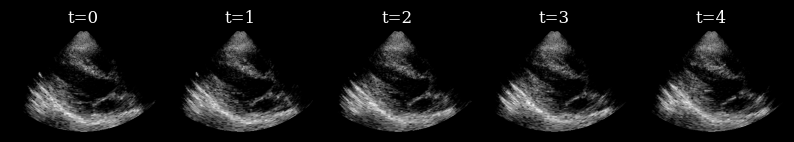

In [57]:
scan_convert = Pipeline([ScanConvert(order=2, jit_compile=False)])
polar_angles = np.asarray(parameters.polar_angles, dtype=float)
parameters_sc = scan_convert.prepare_parameters(
    # the fan the scanner actually swept: the steering angles of the 56 transmits,
    # over the depth range the profile beamformed
    theta_range=(float(polar_angles.min()), float(polar_angles.max())),
    rho_range=tuple(float(v) for v in profile.parameters.zlims),
)


def uncertainty_to_image(variance):
    """Map a variance map onto the image range so it can be plotted beside the images.

    The top percentile is clipped away first, otherwise a handful of hot pixels
    squashes the rest of the map to black.
    """
    upper = np.percentile(ops.convert_to_numpy(variance), 99)
    return translate(ops.clip(variance, 0.0, upper), (0.0, upper), (vmin, vmax))


data_sc = scan_convert(data=data, **parameters_sc)["data"]

n_frames_to_plot = 5
fig, _ = plot_image_grid(
    data_sc[:n_frames_to_plot],
    titles=[f"t={t}" for t in range(n_frames_to_plot)],
    ncols=n_frames_to_plot,
    remove_axis=True,
    vmin=vmin,
    vmax=vmax,
)

## Acquire focused lines
Acquiring a line means firing one focused transmit and beamforming what comes back. That is
exactly what `acquire` does below: it turns the agent's k-hot action into scan line indices,
runs the profile on *only* those lines, and drops them into an otherwise empty frame.

Nothing here fakes an undersampled image by masking a full one — the lines the agent did not
ask for are never formed, and the ones it did are on the same brightness scale as the target
because they share its pinned 0 dB reference.

In [58]:
def fifo_shift(buffer, new_frame):
    """Append `new_frame` to `buffer` along the last (time) axis, dropping the oldest."""
    return ops.concatenate([buffer[..., 1:], new_frame], axis=-1)


def acquire(raw_frame, selected_lines, mask):
    """Beamform the lines the agent selected, straight from the channel data.

    Args:
        raw_frame: `(n_transmits, n_samples, n_elements, 1)` channel data for one frame.
        selected_lines: `(1, n_lines)` k-hot action from the selection policy.
        mask: `(1, height, width)` the same action, at image size.

    Returns:
        The sparse measurement, `(1, height, width)`, and the mask it was taken with.
    """
    line_indices = np.flatnonzero(ops.convert_to_numpy(selected_lines)[0] > 0.5)
    lines_db, _ = beamform(raw_frame, line_indices=line_indices, maxval=reference)

    measurement = np.zeros((frame_height, n_lines), dtype="float32")
    measurement[:, line_indices] = ops.convert_to_numpy(to_model_range(lines_db))
    measurement = np.repeat(measurement, columns_per_line, axis=1)
    return ops.convert_to_tensor(measurement)[None] * mask, mask

### Sampling from the prior


Before any measurements are available, we draw unconditional three-frame clips from the
flow model. Their newest temporal slot defines the initial belief used by greedy variance,
and the first `n_conditional_samples` clips warm-start the first posterior update.


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step


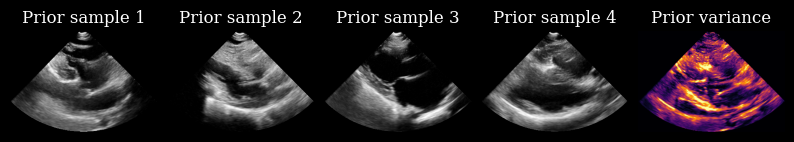

In [59]:
prior_samples = model.sample(
    n_samples=n_prior_samples,
    n_steps=n_unconditional_steps,
    verbose=True,
)

prior_samples_sc = scan_convert(
    data=prior_samples[..., -1], **parameters_sc
)["data"]
prior_variance_sc = scan_convert(
    data=ops.var(prior_samples, axis=0, keepdims=True)[..., -1],
    **(parameters_sc | {"fill_value": 0.0}),
)["data"]

panels = [*prior_samples_sc, uncertainty_to_image(prior_variance_sc[0])]
titles = [
    *[f"Prior sample {i + 1}" for i in range(n_prior_samples)],
    "Prior variance",
]
fig, _ = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * n_prior_samples + ["inferno"],
)


The model generates `n_model_frames` consecutive frames at once, ordered from oldest to
newest, so we condition it on matching measurement and mask windows. These windows keep the
last `n_model_frames` acquisitions in a first-in-first-out buffer. Empty early slots have a
zero mask and therefore do not contribute guidance. The newest posterior slot is the belief
about *now*, which is what the agent uses to choose its next action.

The first update runs the full conditional flow from noise. Later updates warm-start from the
previous posterior samples as-is; only the measurement and mask buffers shift through time.


### Posterior sampling

In [60]:
random_line_selector = UniformRandomLines(
    n_actions=n_actions,
    n_possible_actions=n_lines,
    img_width=frame_width,
    img_height=frame_height,
)
selected_lines, measurement_mask = random_line_selector.sample(batch_size=1)
measurements, measurement_mask = acquire(raw_frames[0], selected_lines, measurement_mask)
# Drop the first measurement into the newest slot of an otherwise empty window.
empty_window = ops.zeros((1, frame_height, frame_width, n_model_frames))
measurement_buffer = fifo_shift(empty_window, measurements[..., None])
mask_buffer = fifo_shift(empty_window, measurement_mask[..., None])
posterior_samples = model.posterior_sample(
    measurements=measurement_buffer,
    mask=mask_buffer,
    n_samples=n_conditional_samples,
    n_steps=n_conditional_steps,
    omega=conditional_omega,
    initial_step=0,
)


In [61]:
# Postprocessing: `posterior_sample` returns (n_samples, height, width, n_model_frames),
# and we look at the newest frame
posterior_samples_sc = scan_convert(data=posterior_samples[..., -1], **parameters_sc)[
    "data"
]
measurements_sc = scan_convert(data=measurements, **parameters_sc)["data"]
variances_sc = scan_convert(
    data=ops.var(posterior_samples, axis=0, keepdims=True)[..., -1],
    **(parameters_sc | {"fill_value": 0.0}),
)["data"]
posterior_mean_sc = scan_convert(
    data=ops.mean(posterior_samples, axis=0, keepdims=True)[..., -1], **parameters_sc
)["data"]

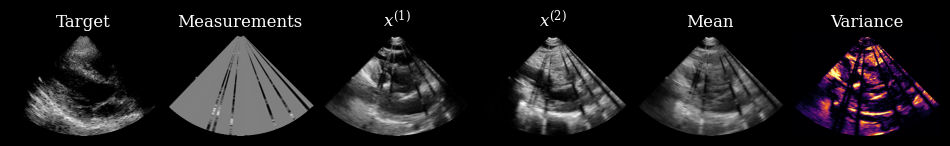

In [62]:
# plot moments of the posterior
panels = [
    data_sc[0],
    measurements_sc[0],
    *posterior_samples_sc,
    posterior_mean_sc[0],
    uncertainty_to_image(variances_sc[0]),
]
titles = [
    "Target",
    "Measurements",
    *[rf"$x^{{({i + 1})}}$" for i in range(n_conditional_samples)],
    "Mean",
    "Variance",
]
fig, ims = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * (len(panels) - 1) + ["inferno"],
)

### A simple action selection function

`zea` ships [`GreedyEntropy`](https://zea.readthedocs.io/en/latest/_autosummary/zea.agent.selection.html#zea.agent.selection.GreedyEntropy),
which scores every pixel by the entropy of a Gaussian mixture fitted to the particles. Here we
write a cheaper cousin that scores pixels by their plain variance, to show how little is needed
to define your own policy: reduce the belief to a per-line uncertainty, then greedily take the
most uncertain line while damping its neighbours (observing one line also tells you something
about the lines next to it).

In [63]:
class GreedyVariance(GreedyEntropy):
    """Greedily select the lines with maximum variance."""

    def sample(self, particles):
        """Sample the action using the greedy variance method.

        Args:
            particles (Tensor): Particles of shape (batch_size, n_particles, height, width)

        Returns:
            Tuple[Tensor, Tensor]:
                - Newly selected lines as k-hot vectors, shaped (batch_size, n_possible_actions)
                - Masks of shape (batch_size, img_height, img_width)
        """
        pixelwise_variance = ops.var(particles, axis=1)  # [batch_size, height, width]
        # we sum across the variances in each column to get a measure of column-wise uncertainty
        columnwise_variance = ops.sum(pixelwise_variance, axis=1)  # [batch_size, width]
        # the prior is wider than the acquisition, so pool the columns each ray fills
        linewise_variance = ops.sum(
            ops.reshape(
                columnwise_variance, (-1, self.n_possible_actions, self.stack_n_cols)
            ),
            axis=2,
        )  # [batch_size, n_possible_actions]

        # Greedily select best line, reweight variances, and repeat
        all_selected_lines = []
        for _ in range(self.n_actions):
            max_variance_line = ops.argmax(linewise_variance, axis=1)
            linewise_variance = self.reweight_entropies_around_line_vmap(
                linewise_variance, max_variance_line
            )
            all_selected_lines.append(max_variance_line)

        selected_lines_k_hot = masks.indices_to_k_hot(
            ops.stack(all_selected_lines, axis=1), self.n_possible_actions
        )
        return selected_lines_k_hot, self.lines_to_im_size(selected_lines_k_hot)

In [64]:
def belief_distribution_to_reconstruction(
    belief_distribution,
    measurements=None,
    measurement_masks=None,
    hard_project=False,
):
    """Choose the first particle and optionally restore exactly measured pixels."""
    reconstruction = belief_distribution[:, 0, ...]
    if not hard_project:
        return reconstruction
    if measurements is None or measurement_masks is None:
        raise ValueError("Hard projection requires measurements and measurement masks")
    measured = measurements[:, 0, ..., None]
    measured_mask = ops.cast(measurement_masks[:, 0, ..., None], "bool")
    return ops.where(measured_mask, measured, reconstruction)


In [65]:
def run_perception_action_loop(raw_frames, action_selector):
    # Greedy variance acts on the prior belief at t=0. The baseline selectors accept
    # the same argument but deliberately ignore it.
    selected_lines, measurement_mask = action_selector.sample(
        prior_samples[None, ..., -1]
    )

    previous_samples = None
    # The last `n_model_frames` measurements and masks, oldest first.
    measurement_buffer = ops.zeros((1, frame_height, frame_width, n_model_frames))
    mask_buffer = ops.zeros_like(measurement_buffer)

    belief_distributions = []
    measurements = []
    measurement_masks = []
    for raw_frame in tqdm(raw_frames):
        measurements_t, measurement_mask_t = acquire(
            raw_frame, selected_lines, measurement_mask
        )
        measurement_buffer = fifo_shift(measurement_buffer, measurements_t[..., None])
        mask_buffer = fifo_shift(mask_buffer, measurement_mask_t[..., None])

        # Run the first frame from noise, then warm-start from each previous posterior.
        initial_step = (
            0 if previous_samples is None else n_initial_conditional_steps
        )
        posterior_samples = model.posterior_sample(
            measurements=measurement_buffer,
            mask=mask_buffer,
            initial_samples=previous_samples,
            n_samples=n_conditional_samples,
            n_steps=n_conditional_steps,
            omega=conditional_omega,
            initial_step=initial_step,
            disable_jit=True,
        )
        # The newest temporal slot is our belief about the current frame.
        belief = posterior_samples[..., -1:]

        selected_lines, measurement_mask = action_selector.sample(belief[None, ..., 0])

        belief_distributions.append(belief)
        measurements.append(measurements_t)
        measurement_masks.append(measurement_mask_t)
        previous_samples = posterior_samples

    return (
        ops.convert_to_tensor(belief_distributions),
        ops.convert_to_tensor(measurements),
        ops.convert_to_tensor(measurement_masks),
    )


In [66]:
# Initialize the action selector and run the perception-action loop.
greedy_variance_action_selector = GreedyVariance(
    n_actions=n_actions,
    n_possible_actions=n_lines,
    img_width=frame_width,
    img_height=frame_height,
)
belief_distributions, measurements, measurement_masks = run_perception_action_loop(
    raw_frames, greedy_variance_action_selector
)


100%|██████████| 32/32 [00:08<00:00,  3.96it/s]


In [67]:
reconstructions = belief_distribution_to_reconstruction(
    belief_distributions,
    measurements,
    measurement_masks,
    hard_project=hard_project,
)
reconstructions_sc = scan_convert(data=reconstructions[..., 0], **parameters_sc)["data"]
measurements_sc = scan_convert(data=measurements[:, 0, ...], **parameters_sc)["data"]
variances_sc = scan_convert(
    data=ops.var(belief_distributions, axis=1)[..., 0],
    **(parameters_sc | {"fill_value": 0.0}),
)["data"]
variances_sc = uncertainty_to_image(variances_sc)


## Visualize the results
Finally, we visualize our reconstructed sequence, along with the selected measurements and posterior variance at each step. The agent's goal of minizing posterior entropy is reflected in the low posterior variance throughout the sequence. You can see that the agent is quickly able to reduce the uncertainty after the first frame, when it was able to observe using acquisition of the first focused lines.

In [68]:
# plot image
fig, ims = plot_image_grid(
    [data_sc[0], measurements_sc[0], reconstructions_sc[0], variances_sc[0]],
    titles=["Target", "Measurements", "Reconstruction", "Variance"],
    ncols=4,
    vmin=vmin,
    vmax=vmax,
    cmap=["gray"] * 3 + ["inferno"],
    figsize=(11, 4),
)


def update(frame):
    ims[0].set_array(data_sc[frame])
    ims[1].set_array(measurements_sc[frame])
    ims[2].set_array(reconstructions_sc[frame])
    ims[3].set_array(variances_sc[frame])

    return ims


ani = animation.FuncAnimation(fig, update, frames=len(data_sc), blit=True, interval=100)
plt.close(fig)
HTML(ani.to_jshtml())

## Does adaptive steering actually pay off?

We have watched one agent reconstruct one sequence, which is a nice picture but not yet
evidence. The claim behind cognitive ultrasound is that *choosing where to look based on what
you currently believe* beats a fixed scan pattern at the same cost. So let us put the agent up
against two belief-agnostic baselines, all spending the exact same budget of
`n_actions` transmits per frame on the same recording:

| Policy | What it does |
| --- | --- |
| **Equispaced sweep** | classic uniform undersampling, shifted one line per frame |
| **Uniform random** | a fresh random subset of lines every frame |
| **Greedy variance** | our agent, steering towards whatever it is least sure about |

We score each with PSNR (pixel fidelity, higher is better) and
[LPIPS](https://zea.readthedocs.io/en/latest/_autosummary/zea.models.lpips.html) (perceptual
distance, lower is better). Both baselines ignore the belief, so we can express them as tiny
subclasses that accept the same `sample(particles)` call and simply throw the particles away.

In [69]:
class RandomLines(UniformRandomLines):
    """Belief-agnostic baseline: a fresh random subset of lines every frame."""

    def sample(self, particles):
        del particles  # a random policy has no use for the belief
        return super().sample(batch_size=1)


class SweepingLines(EquispacedLines):
    """Belief-agnostic baseline: an equispaced grid, swept one line further each frame."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.current_lines = None

    def sample(self, particles):
        del particles  # the sweep is scripted in advance
        self.current_lines, mask = super().sample(self.current_lines)
        return self.current_lines, mask

In [70]:
lpips_model = LPIPS.from_preset("lpips")


def to_lpips(sequence):
    """Grayscale in the model's range -> rgb in [-1, 1], which is what lpips expects."""
    return ops.repeat(translate(sequence, (vmin, vmax), (-1, 1))[..., None], 3, axis=-1)


def evaluate(reconstruction, target):
    """Score a reconstructed sequence against its target, in the polar domain."""
    reconstruction = ops.clip(reconstruction, vmin, vmax)
    psnr = metrics.psnr(target, reconstruction, max_val=vmax - vmin)
    lpips = ops.mean(lpips_model((to_lpips(reconstruction), to_lpips(target))))
    return float(psnr), float(lpips)

In [71]:
selector_kwargs = dict(
    n_actions=n_actions,
    n_possible_actions=n_lines,
    img_width=frame_width,
    img_height=frame_height,
)
baselines = {
    "Equispaced sweep": SweepingLines(**selector_kwargs),
    "Uniform random": RandomLines(**selector_kwargs),
}

# The greedy agent already ran above, so we only pay for the two baselines here.
runs = {}
for name, action_selector in baselines.items():
    print(name)
    beliefs, policy_measurements, policy_masks = run_perception_action_loop(
        raw_frames, action_selector
    )
    runs[name] = belief_distribution_to_reconstruction(
        beliefs,
        policy_measurements,
        policy_masks,
        hard_project=hard_project,
    )[..., 0]
runs["Greedy variance (agent)"] = reconstructions[..., 0]

table = [["Policy", "PSNR (↑)", "LPIPS (↓)"]]
for name, reconstruction in runs.items():
    psnr, lpips = evaluate(reconstruction, data)
    table.append([name, f"{psnr:.2f}", f"{lpips:.3f}"])

print("\n")
print(tabulate(table, headers="firstrow", tablefmt="fancy_grid"))


Equispaced sweep


100%|██████████| 32/32 [00:06<00:00,  5.10it/s]


Uniform random


100%|██████████| 32/32 [00:07<00:00,  4.37it/s]




╒═════════════════════════╤════════════╤═════════════╕
│ Policy                  │   PSNR (↑) │   LPIPS (↓) │
╞═════════════════════════╪════════════╪═════════════╡
│ Equispaced sweep        │      17.34 │       0.476 │
├─────────────────────────┼────────────┼─────────────┤
│ Uniform random          │      17.25 │       0.468 │
├─────────────────────────┼────────────┼─────────────┤
│ Greedy variance (agent) │      18.13 │       0.454 │
╘═════════════════════════╧════════════╧═════════════╛


And the same comparison as a picture, half-way through the loop. Spending the very same
7 transmits per frame, the agent adapts its steering to the current posterior uncertainty.
The equispaced sweep is a strong baseline because it distributes its limited measurements
across the full sector, while uniform random sampling can leave larger gaps. Everything here
is stochastic (the initial line choice and posterior draws), so the exact numbers move between
runs.

Try increasing `n_actions` to 14, or reducing it further, to see how each policy scales with
acquisition budget. The tighter the budget, the more it matters where you spend it — which is
the regime adaptive steering is for.


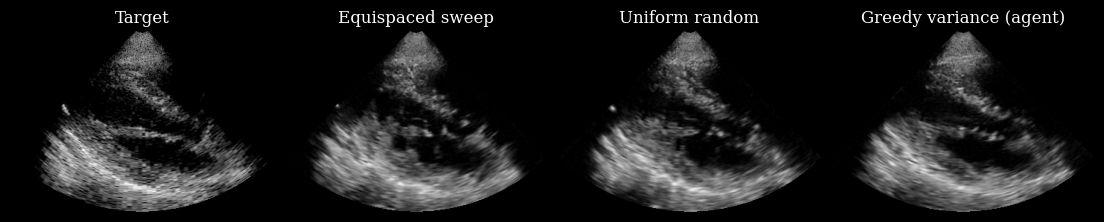

In [72]:
frame = len(data) // 2
panels = [data_sc[frame]]
titles = ["Target"]
for name, reconstruction in runs.items():
    panels.append(
        scan_convert(data=reconstruction[frame][None], **parameters_sc)["data"][0]
    )
    titles.append(name)

fig, _ = plot_image_grid(
    panels,
    titles=titles,
    ncols=len(panels),
    vmin=vmin,
    vmax=vmax,
    figsize=(14, 4),
)

Your turn 🔧 The agent is deliberately simple, and every piece of it is a knob:

- **Action selection.** `GreedyVariance` scores lines by variance. Try `GreedyEntropy`
  (the Gaussian-mixture entropy `zea` ships), or `CovarianceSamplingLines`, or write a
  policy that keeps a memory of where it has already looked.
- **Reconstruction.** `belief_distribution_to_reconstruction` selects the first posterior
  sample. Try returning the posterior mean or median and compare the metrics.
- **Hard projection.** Set `hard_project = True` to exactly restore acquired pixels in the
  displayed and scored reconstruction. Does it help every metric equally?
- **Budget.** Change `n_actions` and see whether the adaptive policy degrades more gracefully
  than the fixed policies.
- **The acquisition itself.** `pipeline/s5-1.yaml` is the whole measurement model. Widen the
  receive aperture with `f_number`, change the depth range with `zlims`, or drop an
  operation and watch what it was doing for you.

See you at IUS 2026! 🎉
